# 1.4 Taxi Trip Cleanup

In this notebook we clean the taxi trip data provided by the city of chicago: https://data.cityofchicago.org/Transportation/Taxi-Trips-2024-/ajtu-isnz/about_data (downloaded on 05.05.2026).

In [2]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
from scipy.stats import zscore
from shapely.geometry import Polygon, Point

import geopandas as gpd
import h3

# reset working dir
import os
from pathlib import Path

In [3]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/hendrik/Coding/Master/AAA


In [4]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

raw_data= pd.read_parquet("data/trips/01_01_fetch_trip_data.parquet")

In [5]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data overview.                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Raw data shape: {raw_data.shape}")
print(f"Raw data info:")
print(raw_data.info())
print(f"Raw data columns: {list(raw_data.columns)}")
raw_data.head()

Raw data shape: (6825838, 23)
Raw data info:
<class 'pandas.DataFrame'>
RangeIndex: 6825838 entries, 0 to 6825837
Data columns (total 23 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_id                     str           
 1   taxi_id                     str           
 2   trip_start_timestamp        datetime64[ns]
 3   trip_end_timestamp          datetime64[ns]
 4   trip_seconds                float64       
 5   trip_miles                  float64       
 6   pickup_census_tract         float64       
 7   dropoff_census_tract        float64       
 8   pickup_community_area       float64       
 9   dropoff_community_area      float64       
 10  fare                        float64       
 11  tips                        float64       
 12  tolls                       float64       
 13  extras                      float64       
 14  trip_total                  float64       
 15  payment_type                str 

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01,2025-01-01 00:15:00,758.0,2.93,NaN,NaN,8.0,8.0,...,0.0,9.75,Prcard,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01,2025-01-01 00:15:00,1233.0,13.66,NaN,NaN,76.0,6.0,...,5.0,48.60,Credit Card,Globe Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)
2,060f692c4ca69e552c07a97c99715ad51112470e,e533bfdc483206f9c02c1c879a118d88f0a3ca1cd2703f...,2025-01-01,2025-01-01 00:00:00,6.0,0.00,NaN,NaN,6.0,6.0,...,0.0,30.50,Credit Card,Flash Cab,41.944227,-87.655998,POINT (-87.6559981815 41.9442266014),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)
3,0b2d1368456148b049af41dc8aa565d688081756,2d5029b701200a2ab66bd5071f743efe20a3036597d2b3...,2025-01-01,2025-01-01 00:00:00,11.0,0.00,NaN,NaN,77.0,77.0,...,0.0,25.62,Credit Card,Sun Taxi,41.986712,-87.663416,POINT (-87.6634164054 41.9867117999),41.986712,-87.663416,POINT (-87.6634164054 41.9867117999)
4,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01,2025-01-01 00:15:00,985.0,3.22,NaN,NaN,8.0,7.0,...,0.0,55.00,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)


In [6]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data type referencing                   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# turn strings to numeric values
stringToNumeric = ["trip_miles", "fare", "tips", "tolls", "extras", "trip_total"]
raw_data[stringToNumeric] = raw_data[stringToNumeric].apply(
    lambda s: pd.to_numeric(
        s.astype(str)
         .str.replace("$", "", regex=False)
         .str.replace(",", ".", regex=False),
        errors="coerce"
    )
)


# Change type of Trip_Start_Timestamp and Trip_End_Timestamp to datetime object
raw_data["trip_start_timestamp"] = pd.to_datetime(
    raw_data["trip_start_timestamp"], format="%Y-%m-%dT%H:%M:%S.%f", errors="coerce"
)

raw_data["trip_end_timestamp"] = pd.to_datetime(
    raw_data["trip_end_timestamp"], format="%Y-%m-%dT%H:%M:%S.%f", errors="coerce"
)

raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6825838 entries, 0 to 6825837
Data columns (total 23 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   trip_id                     str           
 1   taxi_id                     str           
 2   trip_start_timestamp        datetime64[ns]
 3   trip_end_timestamp          datetime64[ns]
 4   trip_seconds                float64       
 5   trip_miles                  float64       
 6   pickup_census_tract         float64       
 7   dropoff_census_tract        float64       
 8   pickup_community_area       float64       
 9   dropoff_community_area      float64       
 10  fare                        float64       
 11  tips                        float64       
 12  tolls                       float64       
 13  extras                      float64       
 14  trip_total                  float64       
 15  payment_type                str           
 16  company                     s

In [7]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Check Time Range                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print("Start Timestamp range:", raw_data["trip_start_timestamp"].min(), "to", raw_data["trip_start_timestamp"].max())

Start Timestamp range: 2025-01-01 00:00:00 to 2025-12-31 23:45:00


In [8]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Remove Duplicates                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Check for duplicates
n_duplicates = raw_data.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

# Check if any trip ids are duplicate
n_duplicate_trip_ids = raw_data["trip_id"].duplicated().sum()
print(f"Number of duplicated Trip IDs: {n_duplicate_trip_ids}")

Number of duplicate rows: 0
Number of duplicated Trip IDs: 0


In [9]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Remove N/A-values                       #
#  (only non-location data)               #
# # # # # # # # # # # # # # # # # # # # # #

# Check for NA values
na_summary = (
    raw_data
    .isna()
    .sum()
    .to_frame(name="Null Count")
    .assign(
        Null_Percent=lambda x: (x["Null Count"] / len(raw_data) * 100).round(2)
    )
)
na_summary

,Null Count,Null_Percent
trip_id,0,0.00
taxi_id,0,0.00
trip_start_timestamp,0,0.00
trip_end_timestamp,128,0.00
trip_seconds,1286,0.02
trip_miles,63,0.00
pickup_census_tract,3745888,54.88
dropoff_census_tract,3833965,56.17
pickup_community_area,186738,2.74
dropoff_community_area,587238,8.60


In [10]:
# Set the columns to check for NA values (e.g., exclude location columns)
columns_to_check = ['taxi_id', 'trip_end_timestamp', 'trip_seconds', 'trip_miles', "fare", "tips", "tolls", "extras", "trip_total"]  # change as needed

# Calculate how many rows would be removed if NA in these columns only
removed_na = raw_data.shape[0] - raw_data.dropna(subset=columns_to_check).shape[0]
removed_rel_share = (removed_na / raw_data.shape[0]) * 100

print(f'Dropping rows with NA in {columns_to_check} would remove {removed_na} rows ({removed_rel_share:.2f}%) of the dataset.')


Dropping rows with NA in ['taxi_id', 'trip_end_timestamp', 'trip_seconds', 'trip_miles', 'fare', 'tips', 'tolls', 'extras', 'trip_total'] would remove 12502 rows (0.18%) of the dataset.


In [11]:
# Remove na values, since only 0.18% of the dataset
raw_data = raw_data.dropna(subset=columns_to_check)

In [12]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Trip Data Cleaning                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Trip miles < 0
n_negative_miles = (raw_data["trip_miles"] <= 0).sum()
print(f"Number of negative trip miles: {n_negative_miles}")

# Trip seconds < 60 (s)
n_seconds_less_min = (raw_data["trip_seconds"] < 60).sum()
print(f"Number of trips faster than 1 min: {n_seconds_less_min}")

# Remove negative trip miles and trips faster than 60s
raw_data = raw_data[((raw_data["trip_miles"] > 0) & (raw_data["trip_seconds"] >= 60))]

overlapping_trips = raw_data.groupby('taxi_id').apply(
    lambda group: group[
        (group['trip_start_timestamp'].lt(group['trip_end_timestamp'].shift(-1))) &
        (group['trip_end_timestamp'].gt(group['trip_start_timestamp'].shift(-1)))
    ]
)
print("Number of Taxi IDs with overlapping operation time periods:", len(overlapping_trips))

# assumption: if there are overlapping trips with the same taxi id, there was something wrong with all of these trips, so therefore we remove all of the overlapping trips
overlapping_trips_indices = overlapping_trips.index.get_level_values(1)
raw_data = raw_data.drop(overlapping_trips_indices, axis= 0)


Number of negative trip miles: 528447


Number of trips faster than 1 min: 381488
Number of Taxi IDs with overlapping operation time periods: 28320


In [13]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Price Data                              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# check for total_prices <= 0
# since tips, tolls and extras are dependent on the details of the trips and might be 0, it is okay for them to be 0.
# Fares are mandatory and have to be greater than 0

fare_check = (raw_data['fare'] <= 0).sum()
tips_check = (raw_data['tips'] < 0).sum()
tolls_check = (raw_data['tolls'] < 0).sum()
extras_check = (raw_data['extras'] < 0).sum()
print("Number of entries with fares <= 0:", fare_check)
print("Number of entries with tips <= 0:", tips_check)
print("Number of entries with tolls <= 0:", tolls_check)
print("Number of entries with extras <= 0:", extras_check)

# remove negative or 0 fares
raw_data = raw_data[raw_data["fare"] > 0]
raw_data.reset_index(drop=True)

Number of entries with fares <= 0: 1455
Number of entries with tips <= 0: 0
Number of entries with tolls <= 0: 0
Number of entries with extras <= 0: 0


,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01 00:00:00,2025-01-01 00:15:00,758.0,2.93,NaN,NaN,8.0,8.0,...,0.0,9.75,Prcard,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01 00:00:00,2025-01-01 00:15:00,1233.0,13.66,NaN,NaN,76.0,6.0,...,5.0,48.60,Credit Card,Globe Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)
2,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01 00:00:00,2025-01-01 00:15:00,985.0,3.22,NaN,NaN,8.0,7.0,...,0.0,55.00,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01 00:00:00,2025-01-01 00:15:00,652.0,3.24,NaN,NaN,22.0,7.0,...,0.0,15.67,Mobile,Tac - Yellow Cab Association,41.922761,-87.699155,POINT (-87.6991553432 41.9227606205),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01 00:00:00,2025-01-01 00:15:00,803.0,6.09,NaN,NaN,8.0,3.0,...,1.0,18.50,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.965812,-87.655879,POINT (-87.6558787862 41.96581197)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6188271,f19c5c32205e7fb37b7ff564da1146484259f8fb,3ae83cc261cea27eafc3d9b18bbc93100c03762e8b6971...,2025-12-31 23:45:00,2026-01-01 00:00:00,960.0,1.70,1.703108e+10,NaN,8.0,NaN,...,0.0,9.50,Cash,Transit Administrative Center Inc,41.895033,-87.619711,POINT (-87.6197106717 41.8950334495),NaN,NaN,
6188272,f1f4fd1497483c42e0f597b0d4e23fef46512bd0,8ac81cfa2ee2c29b19f8fa21ed92b908d46bedc9d4055c...,2025-12-31 23:45:00,2025-12-31 23:45:00,480.0,1.10,NaN,NaN,32.0,32.0,...,1.0,7.75,Cash,Choice Taxi Association Inc,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),41.878866,-87.625192,POINT (-87.6251921424 41.8788655841)
6188273,f25fea09e509dc84b861f98c47cb557701718ffd,54f9ba36584d6915e95cdf3394cdc46ed49c4a57cb0eb2...,2025-12-31 23:45:00,2026-01-01 00:00:00,632.0,3.59,NaN,NaN,32.0,33.0,...,1.0,13.50,Cash,Sun Taxi,41.878866,-87.625192,POINT (-87.6251921424 41.8788655841),41.857184,-87.620335,POINT (-87.6203346241 41.8571838585)
6188274,f6181757bf371eb4d0480e052ed2723d58750bfc,17a313ad40ea410818634782c7202abda7ce5289dc03f9...,2025-12-31 23:45:00,2026-01-01 00:00:00,679.0,2.71,NaN,NaN,8.0,24.0,...,0.0,13.75,Mobile,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.901207,-87.676356,POINT (-87.6763559892 41.9012069941)


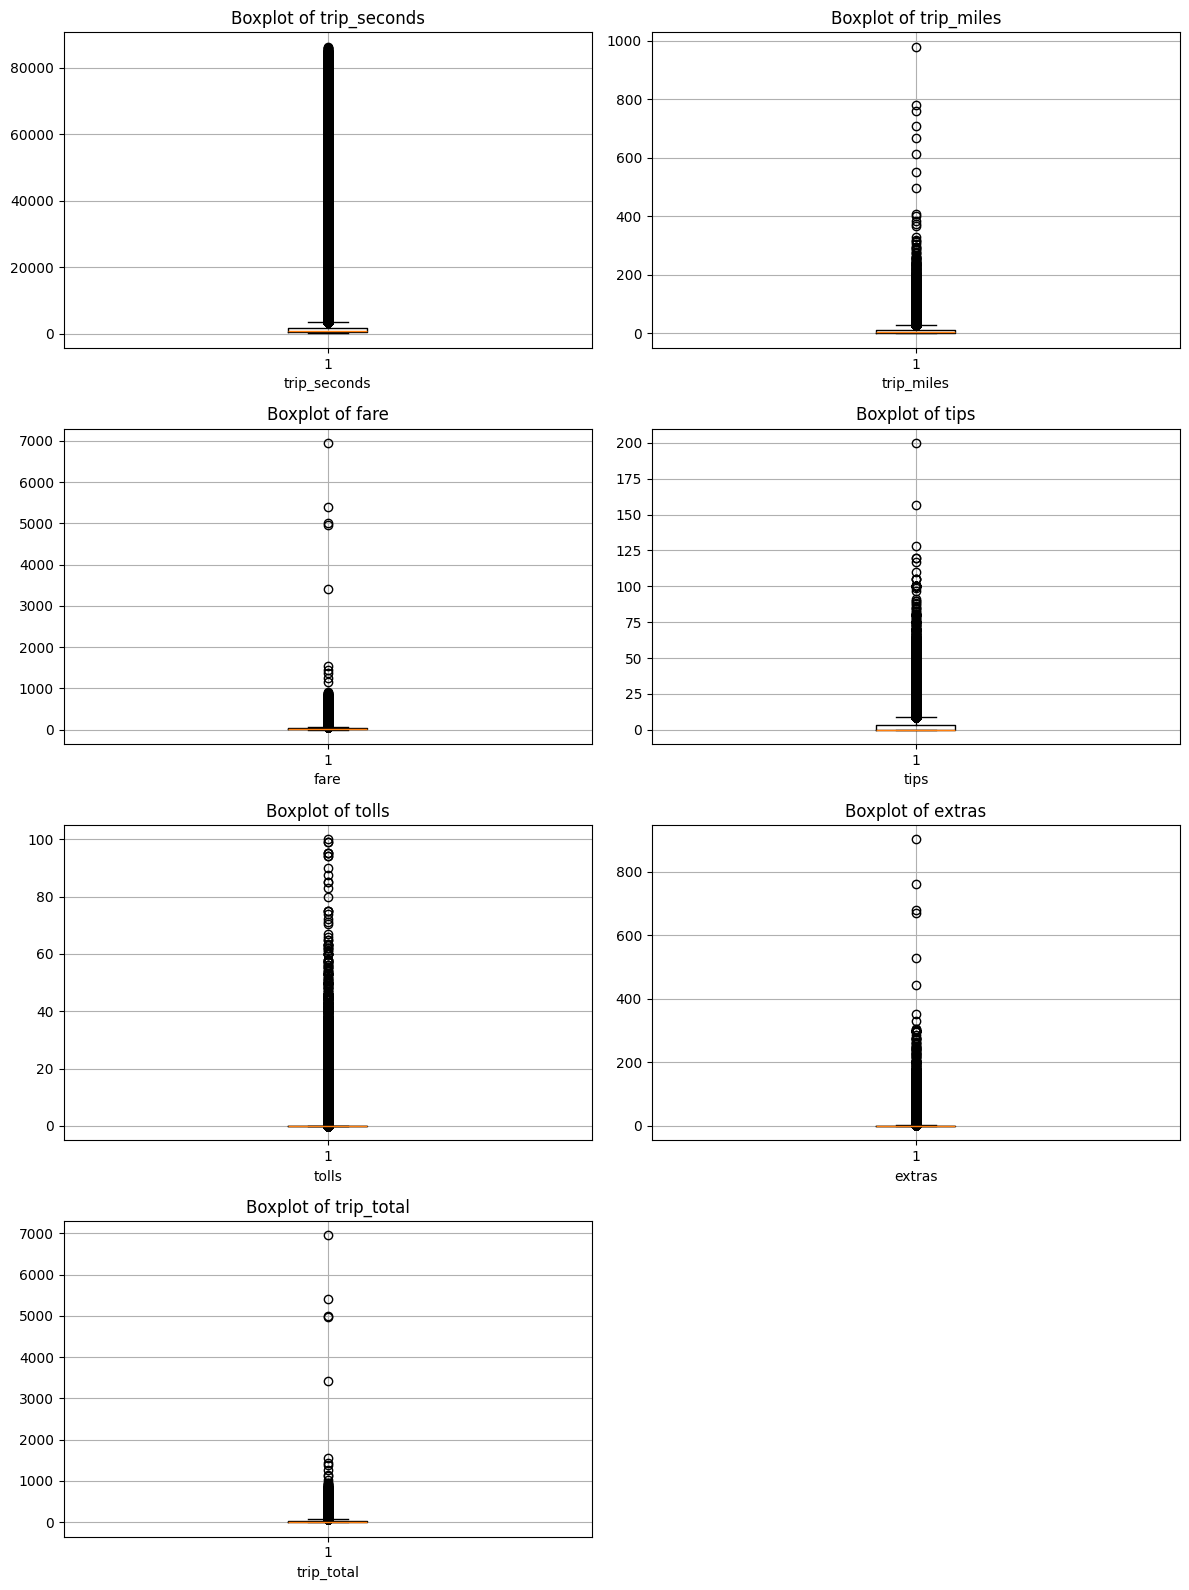

In [14]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Outlier Detection                       #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

numeric_columns = ["trip_seconds", "trip_miles", "fare", "tips", "tolls", "extras", "trip_total"]

# 2 plots per row
rows = math.ceil(len(numeric_columns) / 2)

fig, axes = plt.subplots(rows, 2, figsize=(12, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    data = pd.to_numeric(raw_data[col], errors='coerce').dropna()
    axes[i].boxplot(data, vert=True)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].grid(True)

# Remove any unused axes
for j in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [15]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Outlier Removal: Statistical Solution   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zscore_threshold = 2
outlier_indices_per_column = {}
all_outlier_indices = set()

# remove outliers based on z-score
for col in numeric_columns:
    # Replace zeros with NaN and filter out non-positive values
    safe_col = raw_data[col].replace(0, np.nan)
    safe_col = safe_col[safe_col > 0]
    
    if safe_col.empty:
        continue
    
    # Log-transform and compute z-score
    log_transformed = np.log(safe_col)
    zscores = np.abs(zscore(log_transformed))
    zscore_series = pd.Series(zscores, index=log_transformed.index)

    # Find outliers
    outlier_indices = zscore_series[zscore_series > zscore_threshold].index
    outlier_indices_per_column[col] = list(outlier_indices)
    all_outlier_indices.update(outlier_indices)

    print(f"--> {len(outlier_indices)} outliers detected in '{col}'")

# Drop all outliers at once
total_rows = len(raw_data) # for dropped percentage of dataset
df_cleaned = raw_data.drop(index=all_outlier_indices).reset_index(drop=True)

removed_rows = len(all_outlier_indices)
removed_percentage = round((removed_rows / total_rows) * 100, 2)

print(f"\nOutlier detection completed. Total rows removed: {len(all_outlier_indices)}, {removed_percentage}%")

--> 219896 outliers detected in 'trip_seconds'
--> 94276 outliers detected in 'trip_miles'
--> 55121 outliers detected in 'fare'
--> 52309 outliers detected in 'tips'
--> 2683 outliers detected in 'tolls'
--> 127168 outliers detected in 'extras'
--> 96280 outliers detected in 'trip_total'

Outlier detection completed. Total rows removed: 444102, 7.18%


## Location & spatial cleanup

Starting from the outlier-removed data (`df_cleaned`), we finalise the spatial fields in five steps:

1. **Drop trips with no location data** – an endpoint with no census tract *and* no coordinates *and* no community area cannot be placed, so the trip is removed.
2. **Drop trips that start or end outside the City of Chicago** – decided from the community area / 2010 census tract / coordinates against the official community-area boundaries.
3. **Map census tracts to community areas** – fill any missing community area from the trip's 2010 census tract.
4. **Clean the community-area id** – guarantee every remaining trip has a valid pickup & dropoff community area (no NA).
5. **Assign H3 hexagons** – area-weighted *within each community area* (so cells never cross CA / city boundaries), resolutions 7 and 8.

All reference geometry comes from `tl_2010_17031_tract10` and `Boundaries_Community_Areas_20260608.geojson`.

In [16]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Spatial reference data + normalisation  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Official City of Chicago community-area boundaries (the 77 community areas).
community_areas = gpd.read_file("data/Boundaries_Community_Areas_20260608.geojson").to_crs(4326)
community_areas["community_area"] = community_areas["area_numbe"].astype(int)
community_areas = community_areas[["community_area", "community", "geometry"]]

# City outline (union of all community areas) - used to test raw coordinates.
city_poly = community_areas.geometry.union_all()

# 2010 census tracts (the vintage the taxi data uses), Cook County only.
tracts = (
    gpd.read_file("data/tl_2010_17031_tract10/tl_2010_17031_tract10.shp")
    .rename(columns={"GEOID10": "GEOID"})
    .to_crs(4326)[["GEOID", "geometry"]]
)
TRACT_COL = "GEOID"

# Crosswalk: 2010 census tract -> community area by LARGEST area of overlap.
# (A simple "interior point within a community area" test misclassifies lakefront
# tracts, whose interior point sits in Lake Michigan -- the community-area polygons
# stop at the shoreline. Largest-overlap is robust to that.)
_tr_m = tracts.to_crs(26971)
_tract_area = _tr_m.set_index(TRACT_COL).geometry.area
_ca_m = community_areas.to_crs(26971)[["community_area", "geometry"]]
_ov = gpd.overlay(_tr_m, _ca_m, how="intersection", keep_geom_type=True)
_ov["a"] = _ov.geometry.area
_best = _ov.loc[_ov.groupby(TRACT_COL)["a"].idxmax()].copy()
_best["frac"] = _best["a"].values / _best[TRACT_COL].map(_tract_area).values
# keep a tract as "in city" only if a community area covers >10% of it
# (excludes suburban tracts that merely clip a border community area)
_best = _best[_best["frac"] > 0.10]
tract_to_ca = dict(zip(_best[TRACT_COL], _best["community_area"]))

# --- Normalise the trip location columns on the outlier-clean frame ---
# Census tracts: float (1.7031e10) / NaN  ->  clean GEOID string / <NA>
def to_geoid(s):
    return pd.to_numeric(s, errors="coerce").astype("Int64").astype("string")

df_cleaned["pickup_census_tract"] = to_geoid(df_cleaned["pickup_census_tract"])
df_cleaned["dropoff_census_tract"] = to_geoid(df_cleaned["dropoff_census_tract"])

# Coordinates -> numeric (robust to any comma-decimals)
coord_cols = [
    "pickup_centroid_latitude", "pickup_centroid_longitude",
    "dropoff_centroid_latitude", "dropoff_centroid_longitude",
]
df_cleaned[coord_cols] = df_cleaned[coord_cols].apply(
    lambda s: pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False), errors="coerce")
)

n_city = len(tract_to_ca)
print(f"Community areas: {len(community_areas)}")
print(f"2010 tracts: {len(tracts)}  |  inside Chicago: {n_city}  |  suburban: {len(tracts) - n_city}")

Community areas: 77
2010 tracts: 1319  |  inside Chicago: 799  |  suburban: 520


In [17]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Drop trips with no location             #
# data at all                             #
# # # # # # # # # # # # # # # # # # # # # #

# An endpoint is "locatable" if it has ANY of: census tract, community area or
# coordinates. A trip is dropped when either its pickup or its dropoff has none
# of the three (it cannot be placed anywhere).
def has_location(tract_col, ca_col, lat_col):
    return (
        df_cleaned[tract_col].notna()
        | df_cleaned[ca_col].notna()
        | df_cleaned[lat_col].notna()
    )

pickup_locatable = has_location("pickup_census_tract", "pickup_community_area", "pickup_centroid_latitude")
dropoff_locatable = has_location("dropoff_census_tract", "dropoff_community_area", "dropoff_centroid_latitude")

keep = pickup_locatable & dropoff_locatable
n_before = len(df_cleaned)
n_drop = int((~keep).sum())
print(f"Trips with no pickup location:  {int((~pickup_locatable).sum()):,}")
print(f"Trips with no dropoff location: {int((~dropoff_locatable).sum()):,}")
print(f"Dropping {n_drop:,} trips with no location data "
      f"({n_drop / n_before * 100:.2f}% of {n_before:,}).")

df_cleaned = df_cleaned[keep].reset_index(drop=True)
print(f"Remaining trips: {len(df_cleaned):,}")

Trips with no pickup location:  89,152
Trips with no dropoff location: 337,210
Dropping 370,926 trips with no location data (6.46% of 5,744,174).
Remaining trips: 5,373,248


### Step 2 — Restrict to the City of Chicago

Community areas exist **only** inside Chicago, so an endpoint is *inside the city* when it has a valid community area (1–77), when its 2010 census tract maps to a community area, or — as a fallback — when its coordinate lies within the city outline. Trips that **start or end outside** the city are dropped.

In [18]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Drop trips starting or ending           #
# outside the City of Chicago             #
# # # # # # # # # # # # # # # # # # # # # #

def endpoint_inside(tract_col, ca_col, lat_col, lon_col):
    inside = pd.Series(False, index=df_cleaned.index)

    # (a) valid community area (1..77) -> inside (community areas are city-only)
    ca_num = pd.to_numeric(df_cleaned[ca_col], errors="coerce")
    has_ca = ca_num.between(1, 77)
    inside[has_ca] = True

    # (b) no community area but a census tract -> inside iff tract maps to a CA
    need = ~has_ca & df_cleaned[tract_col].notna()
    inside[need] = df_cleaned.loc[need, tract_col].map(tract_to_ca).notna().values

    # (c) still undecided but has coordinates -> point-in-city test
    need = ~inside & ~has_ca & df_cleaned[tract_col].isna() & df_cleaned[lat_col].notna()
    if need.any():
        pts = gpd.GeoSeries(
            gpd.points_from_xy(df_cleaned.loc[need, lon_col], df_cleaned.loc[need, lat_col]),
            crs=4326,
        )
        inside.loc[need] = pts.within(city_poly).values
    return inside

pickup_inside = endpoint_inside("pickup_census_tract", "pickup_community_area",
                                "pickup_centroid_latitude", "pickup_centroid_longitude")
dropoff_inside = endpoint_inside("dropoff_census_tract", "dropoff_community_area",
                                 "dropoff_centroid_latitude", "dropoff_centroid_longitude")

keep = pickup_inside & dropoff_inside
n_before = len(df_cleaned)
n_drop = int((~keep).sum())
print(f"Pickups outside Chicago:  {int((~pickup_inside).sum()):,}")
print(f"Dropoffs outside Chicago: {int((~dropoff_inside).sum()):,}")
print(f"Dropping {n_drop:,} trips starting or ending outside Chicago "
      f"({n_drop / n_before * 100:.2f}% of {n_before:,}).")

df_cleaned = df_cleaned[keep].reset_index(drop=True)
print(f"Remaining trips: {len(df_cleaned):,}")

Pickups outside Chicago:  31
Dropoffs outside Chicago: 3,862
Dropping 3,892 trips starting or ending outside Chicago (0.07% of 5,373,248).
Remaining trips: 5,369,356


In [19]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Map census tracts to the                #
# correct community areas                 #
# # # # # # # # # # # # # # # # # # # # # #

# Fill any missing community area from the trip's 2010 census tract using the
# tract -> community-area crosswalk. Existing (city-provided) community areas
# are kept as-is.
for direction in ("pickup", "dropoff"):
    ca_col = f"{direction}_community_area"
    tract_col = f"{direction}_census_tract"
    need = df_cleaned[ca_col].isna() & df_cleaned[tract_col].notna()
    filled = df_cleaned.loc[need, tract_col].map(tract_to_ca)
    df_cleaned.loc[need, ca_col] = filled.values
    print(f"{direction}: filled {int(filled.notna().sum()):,} community areas from census tract")

# Convert community area columns to integers
df_cleaned["pickup_community_area"] = df_cleaned["pickup_community_area"].astype(int)
df_cleaned["dropoff_community_area"] = df_cleaned["dropoff_community_area"].astype(int)

df_cleaned.head()

pickup: filled 432 community areas from census tract
dropoff: filled 29,679 community areas from census tract


,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,extras,trip_total,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01,2025-01-01 00:15:00,758.0,2.93,<NA>,<NA>,8,8,...,0.0,9.75,Prcard,Flash Cab,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01,2025-01-01 00:15:00,1233.0,13.66,<NA>,<NA>,76,6,...,5.0,48.60,Credit Card,Globe Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),41.944227,-87.655998,POINT (-87.6559981815 41.9442266014)
2,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01,2025-01-01 00:15:00,985.0,3.22,<NA>,<NA>,8,7,...,0.0,55.00,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01,2025-01-01 00:15:00,652.0,3.24,<NA>,<NA>,22,7,...,0.0,15.67,Mobile,Tac - Yellow Cab Association,41.922761,-87.699155,POINT (-87.6991553432 41.9227606205),41.922686,-87.649489,POINT (-87.6494887289 41.9226862843)
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01,2025-01-01 00:15:00,803.0,6.09,<NA>,<NA>,8,3,...,1.0,18.50,Cash,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.965812,-87.655879,POINT (-87.6558787862 41.96581197)


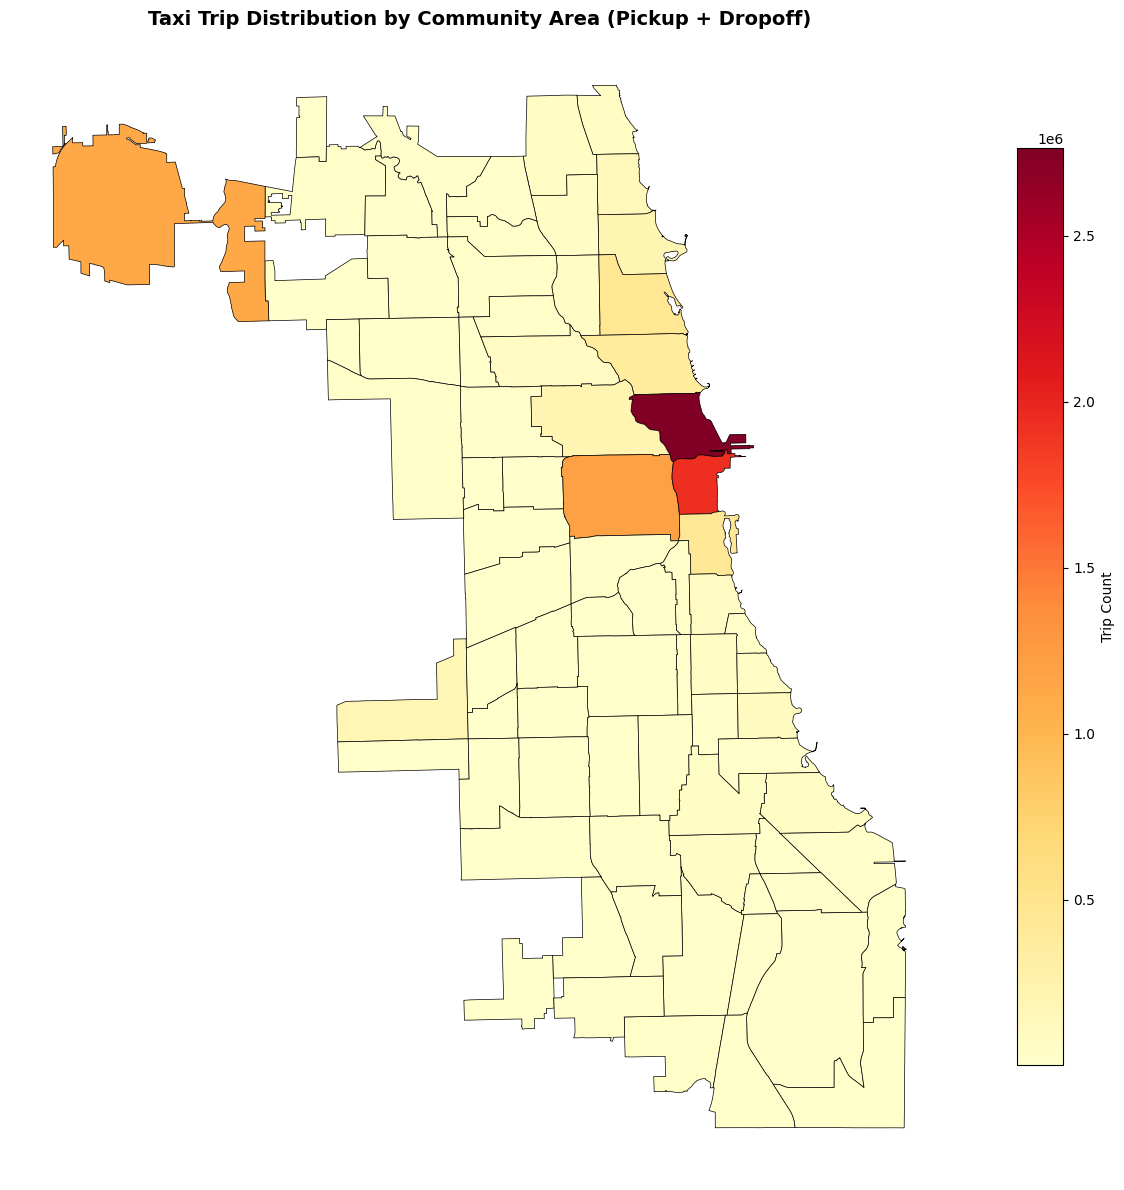

Total trips (pickup + dropoff): 10,738,712
Mean trips per community area: 139464
Top 5 community areas by trip count:
8     2764867
32    1938977
28    1190025
76    1129074
6      465226
Name: trips, dtype: int64


In [20]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualize trip distribution by          #
# community area                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Count trips by community area (pickup and dropoff combined)
trip_counts = (
    pd.concat([
        df_cleaned["pickup_community_area"].value_counts().rename("trips"),
        df_cleaned["dropoff_community_area"].value_counts().rename("trips")
    ])
    .groupby(level=0)
    .sum()
)

# Merge with community areas geometry
ca_viz = community_areas.copy()
ca_viz["trip_count"] = ca_viz["community_area"].map(trip_counts).fillna(0).astype(int)

# Create choropleth
fig, ax = plt.subplots(figsize=(14, 12))
ca_viz.plot(
    ax=ax,
    column="trip_count",
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "Trip Count", "shrink": 0.8},
    edgecolor="black",
    linewidth=0.5,
)
ax.set_title("Taxi Trip Distribution by Community Area (Pickup + Dropoff)", fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Total trips (pickup + dropoff): {trip_counts.sum():,}")
print(f"Mean trips per community area: {trip_counts.mean():.0f}")
print(f"Top 5 community areas by trip count:")
print(trip_counts.nlargest(5))

In [21]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# H3 hexagons (area-weighted              #
# within each community area)             #
# # # # # # # # # # # # # # # # # # # # # #

# For each community area we find every H3 cell that overlaps it and weight the
# cells by their share of the community area's footprint (weights sum to 1 per
# CA). Each trip is then probabilistically assigned a hexagon from its
# community area's distribution, so assignments never leak across CA / city
# boundaries. Only resolutions 6 and 7 are produced.
H3_RESOLUTIONS = {"res6": 6, "res7": 7}

def build_ca_hex_coverage(ca_gdf, res_level):
    rows = []
    for _, row in ca_gdf.iterrows():
        ca_id = row["community_area"]
        geom = row.geometry
        parts = list(geom.geoms) if geom.geom_type == "MultiPolygon" else [geom]
        cells = set()
        for part in parts:
            cells.update(h3.geo_to_cells(part.__geo_interface__, res_level))
        if not cells:  # community area smaller than one H3 cell
            c = geom.centroid
            cells = {h3.latlng_to_cell(c.y, c.x, res_level)}
        candidates = set(cells)
        for cell in cells:
            candidates.update(h3.grid_disk(cell, 1))  # catch border cells
        for cell in candidates:
            hex_poly = Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(cell)])
            area = geom.intersection(hex_poly).area
            if area > 0:
                rows.append({"community_area": ca_id, "h3_cell": cell, "area": area})
    cov = pd.DataFrame(rows)
    cov["weight"] = cov["area"] / cov.groupby("community_area")["area"].transform("sum")
    return cov[["community_area", "h3_cell", "weight"]]

coverage = {}
for res_name, res_level in H3_RESOLUTIONS.items():
    print(f"Building H3 coverage for {res_name} (level {res_level}) …", flush=True)
    coverage[res_name] = build_ca_hex_coverage(community_areas, res_level)
    print(f"  → {len(coverage[res_name]):,} community-area/cell pairs")

# Probabilistic assignment per community area
rng = np.random.default_rng(42)
for res_name in H3_RESOLUTIONS:
    lookup = {
        ca_id: (grp["h3_cell"].values, grp["weight"].values)
        for ca_id, grp in coverage[res_name].groupby("community_area")
    }
    for direction in ("pickup", "dropoff"):
        ca_col = f"{direction}_community_area"
        h3_col = f"{direction}_h3_{res_name}"
        result = pd.Series(index=df_cleaned.index, dtype=object)
        for ca_id, idx in df_cleaned.groupby(ca_col).groups.items():
            if ca_id not in lookup:
                continue
            cells, weights = lookup[ca_id]
            result[idx] = rng.choice(cells, size=len(idx), p=weights)
        df_cleaned[h3_col] = result

    pu_na = int(df_cleaned[f"pickup_h3_{res_name}"].isna().sum())
    do_na = int(df_cleaned[f"dropoff_h3_{res_name}"].isna().sum())
    print(f"{res_name}: pickup NAs={pu_na:,}  dropoff NAs={do_na:,}")

Building H3 coverage for res6 (level 6) …
  → 180 community-area/cell pairs
Building H3 coverage for res7 (level 7) …
  → 434 community-area/cell pairs
res6: pickup NAs=0  dropoff NAs=0
res7: pickup NAs=0  dropoff NAs=0


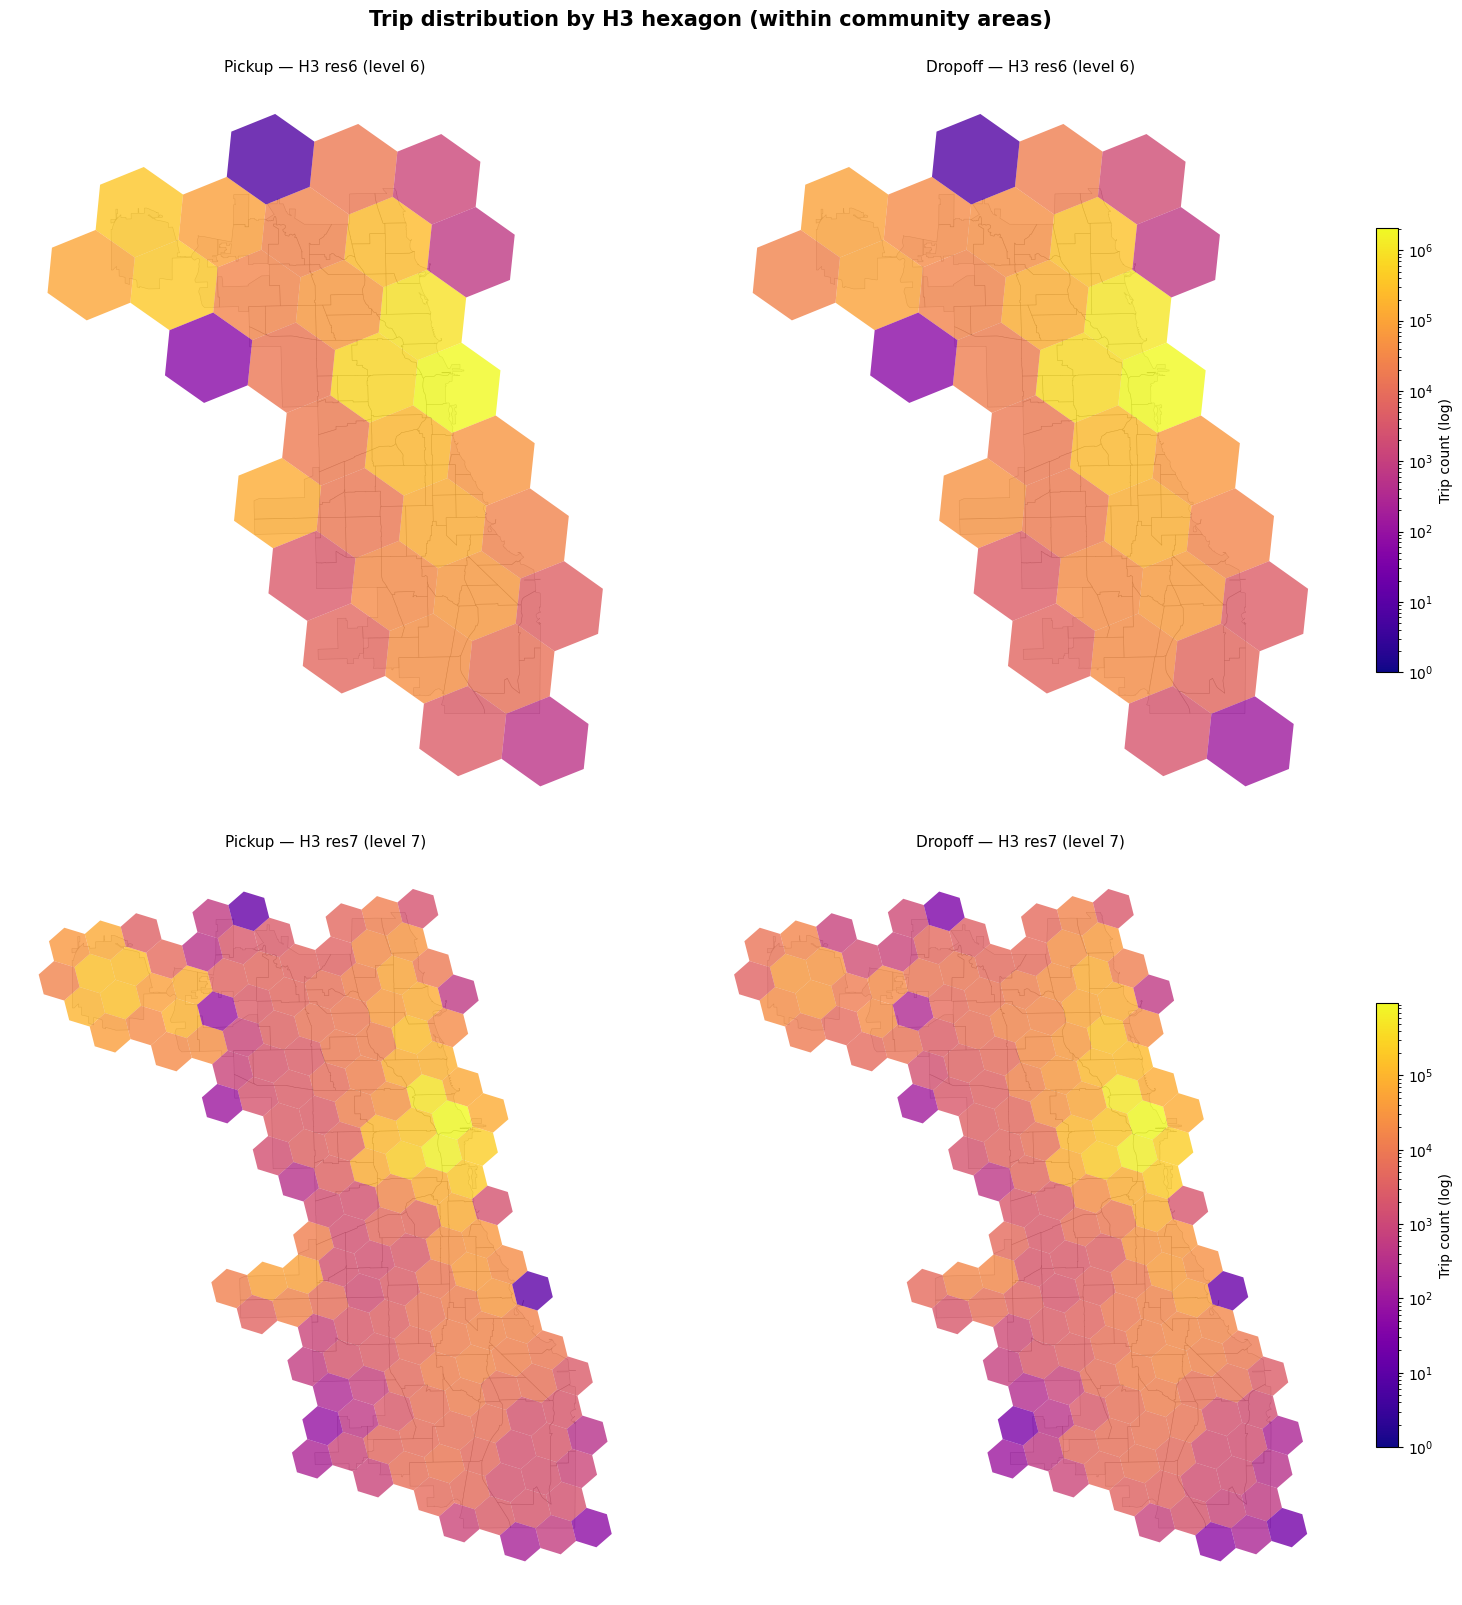

In [22]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# H3 distribution plots (verification)    #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(len(H3_RESOLUTIONS), 2, figsize=(16, 8 * len(H3_RESOLUTIONS)))

for row_idx, (res_name, res_level) in enumerate(H3_RESOLUTIONS.items()):
    for col_idx, direction in enumerate(("pickup", "dropoff")):
        ax = axes[row_idx, col_idx]
        counts = df_cleaned[f"{direction}_h3_{res_name}"].value_counts().dropna()

        polys = [Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(c)]) for c in counts.index]
        hex_gdf = gpd.GeoDataFrame({"count": counts.values, "geometry": polys}, crs=4326)

        # Base layer: community-area outlines
        community_areas.plot(ax=ax, facecolor="lightgray", edgecolor="black", linewidth=0.4, alpha=0.4)

        # H3 layer coloured by trip count
        hex_gdf.plot(
            ax=ax, column="count", cmap="plasma",
            norm=LogNorm(vmin=1, vmax=counts.max()),
            legend=(col_idx == 1),
            legend_kwds={"label": "Trip count (log)", "shrink": 0.6},
            alpha=0.8, edgecolor="none",
        )
        ax.set_title(f"{direction.capitalize()} — H3 {res_name} (level {res_level})", fontsize=11)
        ax.set_axis_off()

plt.suptitle("Trip distribution by H3 hexagon (within community areas)", fontsize=15, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

In [23]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Final data quality checks               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Check for null values
null_summary = (
    df_cleaned
    .isna()
    .sum()
    .to_frame(name="Null Count")
    .assign(
        Null_Percent=lambda x: (x["Null Count"] / len(df_cleaned) * 100).round(2)
    )
)
print("Null values in cleaned dataset:")
print(null_summary[null_summary["Null Count"] > 0])
print()

# Drop census tract columns (we're using community areas instead)
df_cleaned = df_cleaned.drop(columns=["pickup_census_tract", "dropoff_census_tract", "pickup_centroid_location", "dropoff_centroid_location"], errors="ignore")
print("Dropped census tract columns: pickup_census_tract, dropoff_census_tract, pickup_centroid_location, dropoff_centroid_location")
print(f"Remaining columns: {list(df_cleaned.columns)}")

df_cleaned

Null values in cleaned dataset:
                      Null Count  Null_Percent
pickup_census_tract      2860429         53.27
dropoff_census_tract     2860429         53.27

Dropped census tract columns: pickup_census_tract, dropoff_census_tract, pickup_centroid_location, dropoff_centroid_location
Remaining columns: ['trip_id', 'taxi_id', 'trip_start_timestamp', 'trip_end_timestamp', 'trip_seconds', 'trip_miles', 'pickup_community_area', 'dropoff_community_area', 'fare', 'tips', 'tolls', 'extras', 'trip_total', 'payment_type', 'company', 'pickup_centroid_latitude', 'pickup_centroid_longitude', 'dropoff_centroid_latitude', 'dropoff_centroid_longitude', 'pickup_h3_res6', 'dropoff_h3_res6', 'pickup_h3_res7', 'dropoff_h3_res7']


,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare,tips,...,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,pickup_h3_res6,dropoff_h3_res6,pickup_h3_res7,dropoff_h3_res7
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01 00:00:00,2025-01-01 00:15:00,758.0,2.93,8,8,9.75,0.00,...,Prcard,Flash Cab,41.899602,-87.633308,41.899602,-87.633308,862664c17ffffff,862664c1fffffff,872664c1effffff,872664c1cffffff
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01 00:00:00,2025-01-01 00:15:00,1233.0,13.66,76,6,35.00,8.10,...,Credit Card,Globe Taxi,41.980264,-87.913625,41.944227,-87.655998,86275936fffffff,862664c17ffffff,87275934effffff,872664c16ffffff
2,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01 00:00:00,2025-01-01 00:15:00,985.0,3.22,8,7,55.00,0.00,...,Cash,City Service,41.899602,-87.633308,41.922686,-87.649489,862664c17ffffff,862664c17ffffff,872664c13ffffff,872664c12ffffff
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01 00:00:00,2025-01-01 00:15:00,652.0,3.24,22,7,11.67,4.00,...,Mobile,Tac - Yellow Cab Association,41.922761,-87.699155,41.922686,-87.649489,862664ca7ffffff,862664c17ffffff,872664c12ffffff,872664c12ffffff
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01 00:00:00,2025-01-01 00:15:00,803.0,6.09,8,3,17.50,0.00,...,Cash,City Service,41.899602,-87.633308,41.965812,-87.655879,862664c17ffffff,862664d8fffffff,872664c1effffff,872664c14ffffff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5369351,f0fce143dbea9334c1ceb9ae2b28f9ddeebfe49c,f0d6376865e19a2dae04d7d5401649247eb526372356ac...,2025-12-31 23:45:00,2026-01-01 00:00:00,659.0,2.02,32,33,11.10,0.00,...,Mobile,Taxicab Insurance Agency Llc,41.878866,-87.625192,41.857184,-87.620335,862664c1fffffff,862664c1fffffff,872664c1affffff,872664c1bffffff
5369352,f1f4fd1497483c42e0f597b0d4e23fef46512bd0,8ac81cfa2ee2c29b19f8fa21ed92b908d46bedc9d4055c...,2025-12-31 23:45:00,2025-12-31 23:45:00,480.0,1.10,32,32,6.75,0.00,...,Cash,Choice Taxi Association Inc,41.878866,-87.625192,41.878866,-87.625192,862664c1fffffff,862664c1fffffff,872664c1affffff,872664c1affffff
5369353,f25fea09e509dc84b861f98c47cb557701718ffd,54f9ba36584d6915e95cdf3394cdc46ed49c4a57cb0eb2...,2025-12-31 23:45:00,2026-01-01 00:00:00,632.0,3.59,32,33,12.50,0.00,...,Cash,Sun Taxi,41.878866,-87.625192,41.857184,-87.620335,862664c1fffffff,862664c1fffffff,872664c1affffff,872664c1affffff
5369354,f6181757bf371eb4d0480e052ed2723d58750bfc,17a313ad40ea410818634782c7202abda7ce5289dc03f9...,2025-12-31 23:45:00,2026-01-01 00:00:00,679.0,2.71,8,24,10.50,2.75,...,Mobile,Flash Cab,41.899602,-87.633308,41.901207,-87.676356,862664c1fffffff,862664cafffffff,872664c1effffff,872664ca8ffffff


In [24]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Write cleaned data                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

df_cleaned.to_parquet("data/trips/01_04_trips_clean.parquet", index=False)
print(f"Wrote {len(df_cleaned):,} cleaned trips to data/trips/01_04_trips_clean.parquet")

Wrote 5,369,356 cleaned trips to data/trips/01_04_trips_clean.parquet
